## Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import combinations
import json
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries loaded")

✓ Libraries loaded


## Configuration

In [3]:
# Paths
PREPROCESSED_DIR = Path("./Preprocessed_Data")
OUTPUT_DIR = Path("./Multi_Session_Jaccard_Output")
OUTPUT_DIR.mkdir(exist_ok=True)

# Correlation thresholds to test
THRESHOLDS = [0.3, 0.4, 0.5, 0.6, 0.7]

print(f"Preprocessed data directory: {PREPROCESSED_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Thresholds to test: {THRESHOLDS}")

Preprocessed data directory: Preprocessed_Data
Output directory: Multi_Session_Jaccard_Output
Thresholds to test: [0.3, 0.4, 0.5, 0.6, 0.7]


## Step 1: Identify Multi-Session Subjects

Find all subjects that have data from multiple recording sessions.

In [4]:
# Load preprocessing summary
summary_df = pd.read_csv(PREPROCESSED_DIR / 'preprocessing_summary.csv')

# Filter successful preprocessing only
summary_df = summary_df[summary_df['status'] == 'success'].copy()

# Count sessions per subject
session_counts = summary_df.groupby('subject_id').size().reset_index(name='n_sessions')
multi_session_subjects = session_counts[session_counts['n_sessions'] > 1]['subject_id'].tolist()

print(f"Total subjects with successful preprocessing: {len(session_counts)}")
print(f"Subjects with multiple sessions: {len(multi_session_subjects)}")
print(f"\nMulti-session subjects:")
for subj in multi_session_subjects:
    sessions = summary_df[summary_df['subject_id'] == subj]['session_id'].tolist()
    print(f"  {subj}: {sessions}")

Total subjects with successful preprocessing: 103
Subjects with multiple sessions: 21

Multi-session subjects:
  sub-NORB00064: ['ses-2', 'ses-3', 'ses-1']
  sub-NORB00065: ['ses-2', 'ses-1']
  sub-NORB00069: ['ses-2', 'ses-3', 'ses-1', 'ses-4']
  sub-NORB00070: ['ses-2', 'ses-3', 'ses-1']
  sub-NORB00074: ['ses-2', 'ses-1']
  sub-NORB00075: ['ses-2', 'ses-3', 'ses-1']
  sub-NORB00077: ['ses-2', 'ses-1']
  sub-NORB00078: ['ses-2', 'ses-1']
  sub-NORB00079: ['ses-2', 'ses-1']
  sub-NORB00080: ['ses-2', 'ses-1']
  sub-NORB00081: ['ses-2', 'ses-1']
  sub-NORB00083: ['ses-2', 'ses-1']
  sub-NORB00084: ['ses-2', 'ses-1']
  sub-NORB00085: ['ses-2', 'ses-1']
  sub-NORB00086: ['ses-2', 'ses-1']
  sub-NORB00087: ['ses-2', 'ses-1']
  sub-NORB00089: ['ses-2', 'ses-1']
  sub-NORB00090: ['ses-2', 'ses-1']
  sub-NORB00094: ['ses-2', 'ses-1']
  sub-NORB00096: ['ses-2', 'ses-1']
  sub-NORB00103: ['ses-2', 'ses-1']


## Step 2: Helper Functions

In [5]:
def load_preprocessed_epochs(subject_id, session_id, preprocessed_dir):
    """Load preprocessed epoch data for a subject-session"""
    npy_file = preprocessed_dir / f"{subject_id}_{session_id}_preprocessed.npy"
    meta_file = preprocessed_dir / f"{subject_id}_{session_id}_metadata.json"
    
    if not npy_file.exists():
        return None, None
    
    epochs_data = np.load(npy_file)
    
    with open(meta_file, 'r') as f:
        metadata = json.load(f)
    
    return epochs_data, metadata

def compute_correlation_matrix(epochs_data):
    """Compute average correlation matrix across all epochs"""
    n_epochs, n_channels, n_times = epochs_data.shape
    
    # Average each epoch across time
    epoch_means = np.mean(epochs_data, axis=2)  # (n_epochs, n_channels)
    
    # Compute correlation matrix
    corr_matrix = np.corrcoef(epoch_means.T)  # (n_channels, n_channels)
    
    # Set diagonal to 0 (remove self-correlations)
    np.fill_diagonal(corr_matrix, 0)
    
    return corr_matrix

def threshold_matrix(corr_matrix, threshold):
    """Convert correlation matrix to binary adjacency matrix"""
    return (np.abs(corr_matrix) >= threshold).astype(int)

def jaccard_index(adj_matrix1, adj_matrix2):
    """Calculate Jaccard Index between two adjacency matrices"""
    # Get upper triangle indices (undirected graph)
    triu_indices = np.triu_indices_from(adj_matrix1, k=1)
    
    edges1 = adj_matrix1[triu_indices]
    edges2 = adj_matrix2[triu_indices]
    
    # Calculate intersection and union
    intersection = np.sum(edges1 & edges2)
    union = np.sum(edges1 | edges2)
    
    if union == 0:
        return 0.0
    
    return intersection / union

def align_channels(epochs_data1, channels1, epochs_data2, channels2):
    """Align two datasets to have the same channels"""
    common_channels = list(set(channels1) & set(channels2))
    common_channels.sort()
    
    if len(common_channels) == 0:
        return None, None, []
    
    # Get indices for common channels
    idx1 = [channels1.index(ch) for ch in common_channels]
    idx2 = [channels2.index(ch) for ch in common_channels]
    
    # Select only common channels
    aligned_data1 = epochs_data1[:, idx1, :]
    aligned_data2 = epochs_data2[:, idx2, :]
    
    return aligned_data1, aligned_data2, common_channels

print("✓ Helper functions defined")

✓ Helper functions defined


## Step 3: Calculate Jaccard Index for All Session Pairs

For each subject with multiple sessions, compute Jaccard Index at different correlation thresholds.

In [6]:
results = []

for subject_id in multi_session_subjects:
    # Get all sessions for this subject
    sessions = summary_df[summary_df['subject_id'] == subject_id]['session_id'].tolist()
    
    # Get all unique pairs of sessions
    session_pairs = list(combinations(sessions, 2))
    
    for session1, session2 in session_pairs:
        print(f"\nProcessing {subject_id}: {session1} vs {session2}")
        
        # Load data
        epochs_data1, meta1 = load_preprocessed_epochs(subject_id, session1, PREPROCESSED_DIR)
        epochs_data2, meta2 = load_preprocessed_epochs(subject_id, session2, PREPROCESSED_DIR)
        
        if epochs_data1 is None or epochs_data2 is None:
            print(f"  Skipping: Data not found")
            continue
        
        # Align channels
        aligned_data1, aligned_data2, common_channels = align_channels(
            epochs_data1, meta1['channels'],
            epochs_data2, meta2['channels']
        )
        
        if aligned_data1 is None:
            print(f"  Skipping: No common channels")
            continue
        
        print(f"  Common channels: {len(common_channels)}")
        print(f"  Epochs: {len(aligned_data1)} vs {len(aligned_data2)}")
        
        # Compute correlation matrices
        corr_matrix1 = compute_correlation_matrix(aligned_data1)
        corr_matrix2 = compute_correlation_matrix(aligned_data2)
        
        # Calculate Jaccard at different thresholds
        for threshold in THRESHOLDS:
            adj_matrix1 = threshold_matrix(corr_matrix1, threshold)
            adj_matrix2 = threshold_matrix(corr_matrix2, threshold)
            
            jaccard = jaccard_index(adj_matrix1, adj_matrix2)
            
            # Count edges
            n_edges1 = np.sum(np.triu(adj_matrix1, k=1))
            n_edges2 = np.sum(np.triu(adj_matrix2, k=1))
            
            results.append({
                'subject_id': subject_id,
                'session1': session1,
                'session2': session2,
                'threshold': threshold,
                'jaccard_index': jaccard,
                'n_common_channels': len(common_channels),
                'n_epochs_ses1': len(aligned_data1),
                'n_epochs_ses2': len(aligned_data2),
                'n_edges_ses1': n_edges1,
                'n_edges_ses2': n_edges2
            })
            
            print(f"    Threshold {threshold}: Jaccard = {jaccard:.3f} (edges: {n_edges1} vs {n_edges2})")

# Convert to DataFrame
results_df = pd.DataFrame(results)
print(f"\n{'='*60}")
print(f"Total comparisons: {len(results_df) // len(THRESHOLDS)}")
print(f"Total results (all thresholds): {len(results_df)}")


Processing sub-NORB00064: ses-2 vs ses-3
  Common channels: 19
  Epochs: 20 vs 17
    Threshold 0.3: Jaccard = 0.094 (edges: 30 vs 40)
    Threshold 0.4: Jaccard = 0.069 (edges: 14 vs 17)
    Threshold 0.5: Jaccard = 0.000 (edges: 8 vs 7)
    Threshold 0.6: Jaccard = 0.000 (edges: 5 vs 4)
    Threshold 0.7: Jaccard = 0.000 (edges: 0 vs 0)

Processing sub-NORB00064: ses-2 vs ses-1
  Common channels: 19
  Epochs: 20 vs 13
    Threshold 0.3: Jaccard = 0.118 (edges: 30 vs 65)
    Threshold 0.4: Jaccard = 0.089 (edges: 14 vs 35)
    Threshold 0.5: Jaccard = 0.042 (edges: 8 vs 17)
    Threshold 0.6: Jaccard = 0.000 (edges: 5 vs 6)
    Threshold 0.7: Jaccard = 0.000 (edges: 0 vs 2)

Processing sub-NORB00064: ses-3 vs ses-1
  Common channels: 19
  Epochs: 17 vs 13
    Threshold 0.3: Jaccard = 0.141 (edges: 40 vs 65)
    Threshold 0.4: Jaccard = 0.083 (edges: 17 vs 35)
    Threshold 0.5: Jaccard = 0.000 (edges: 7 vs 17)
    Threshold 0.6: Jaccard = 0.000 (edges: 4 vs 6)
    Threshold 0.7: Jacc

## Step 4: Save Results

In [7]:
# Save detailed results
results_df.to_csv(OUTPUT_DIR / 'multi_session_jaccard_results.csv', index=False)
print(f"Saved: {OUTPUT_DIR / 'multi_session_jaccard_results.csv'}")

# Create summary statistics
summary_stats = results_df.groupby('threshold').agg({
    'jaccard_index': ['mean', 'std', 'min', 'max', 'median'],
    'subject_id': 'count'
}).reset_index()
summary_stats.columns = ['threshold', 'mean_jaccard', 'std_jaccard', 'min_jaccard', 'max_jaccard', 'median_jaccard', 'n_comparisons']
summary_stats.to_csv(OUTPUT_DIR / 'jaccard_summary_by_threshold.csv', index=False)
print(f"Saved: {OUTPUT_DIR / 'jaccard_summary_by_threshold.csv'}")

print("\nSummary by threshold:")
print(summary_stats.to_string(index=False))

Saved: Multi_Session_Jaccard_Output/multi_session_jaccard_results.csv
Saved: Multi_Session_Jaccard_Output/jaccard_summary_by_threshold.csv

Summary by threshold:
 threshold  mean_jaccard  std_jaccard  min_jaccard  max_jaccard  median_jaccard  n_comparisons
       0.3      0.118350     0.066912          0.0      0.31068        0.119799             32
       0.4      0.047247     0.040815          0.0      0.15625        0.043478             32
       0.5      0.007759     0.026699          0.0      0.12500        0.000000             32
       0.6      0.000000     0.000000          0.0      0.00000        0.000000             32
       0.7      0.000000     0.000000          0.0      0.00000        0.000000             32


## Step 5: Visualizations

### 5.1 Jaccard Index Distribution by Threshold

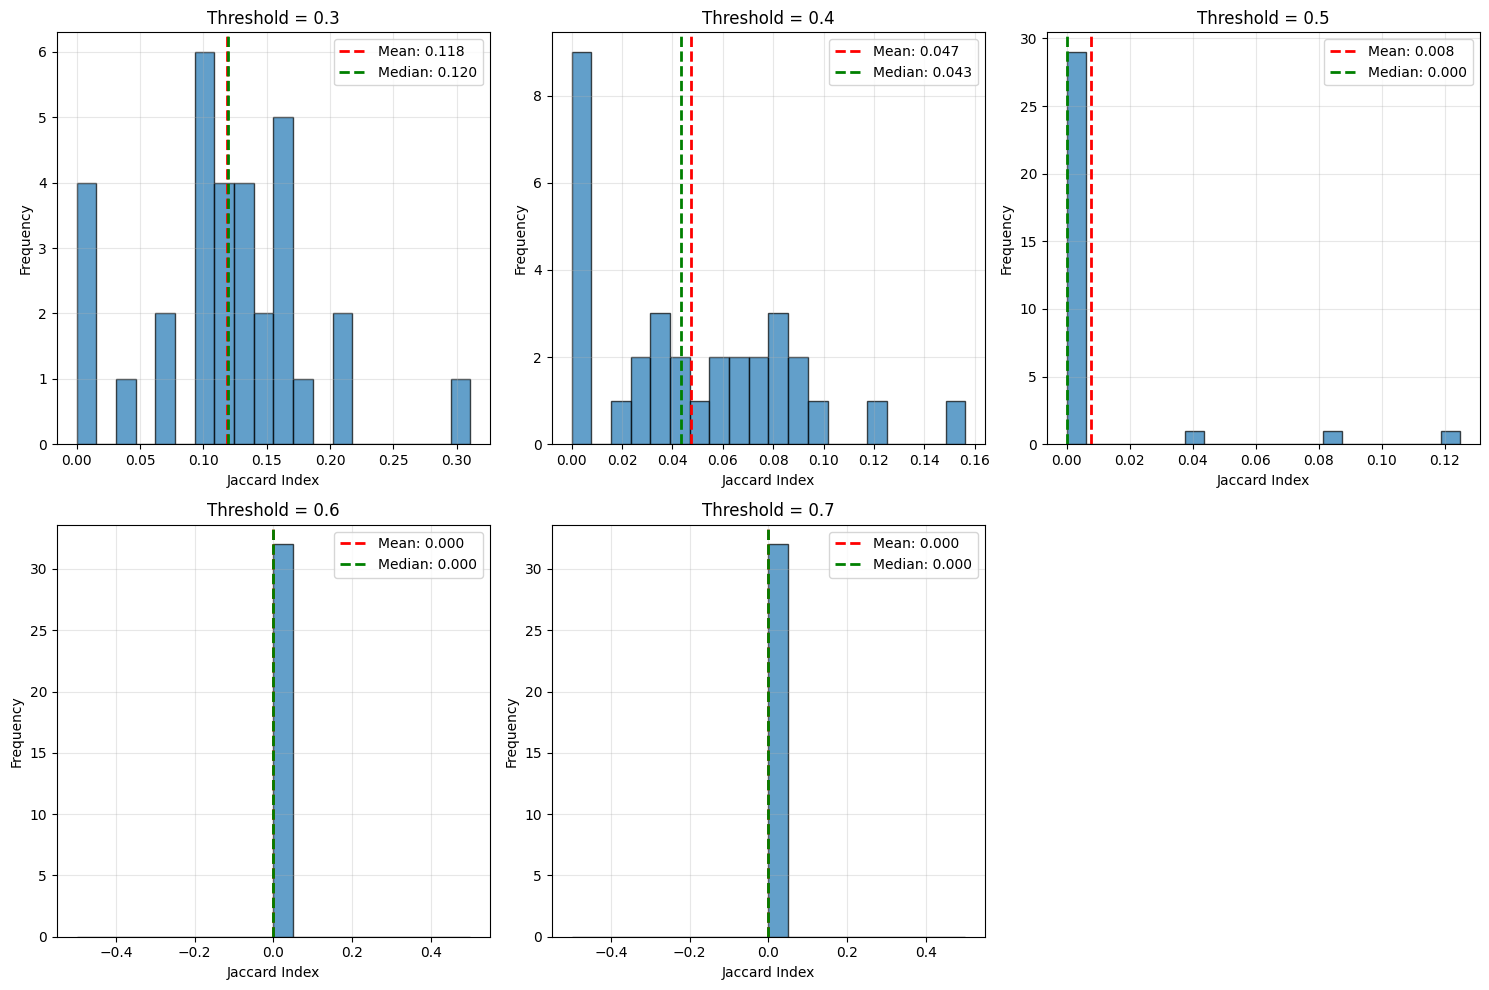

Saved: Multi_Session_Jaccard_Output/jaccard_distribution_by_threshold.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, threshold in enumerate(THRESHOLDS):
    data = results_df[results_df['threshold'] == threshold]['jaccard_index']
    
    axes[idx].hist(data, bins=20, edgecolor='black', alpha=0.7)
    axes[idx].axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.3f}')
    axes[idx].axvline(data.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {data.median():.3f}')
    axes[idx].set_xlabel('Jaccard Index')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Threshold = {threshold}')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

# Hide extra subplot
axes[-1].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'jaccard_distribution_by_threshold.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'jaccard_distribution_by_threshold.png'}")

### 5.2 Jaccard Index vs Threshold (Box Plot)

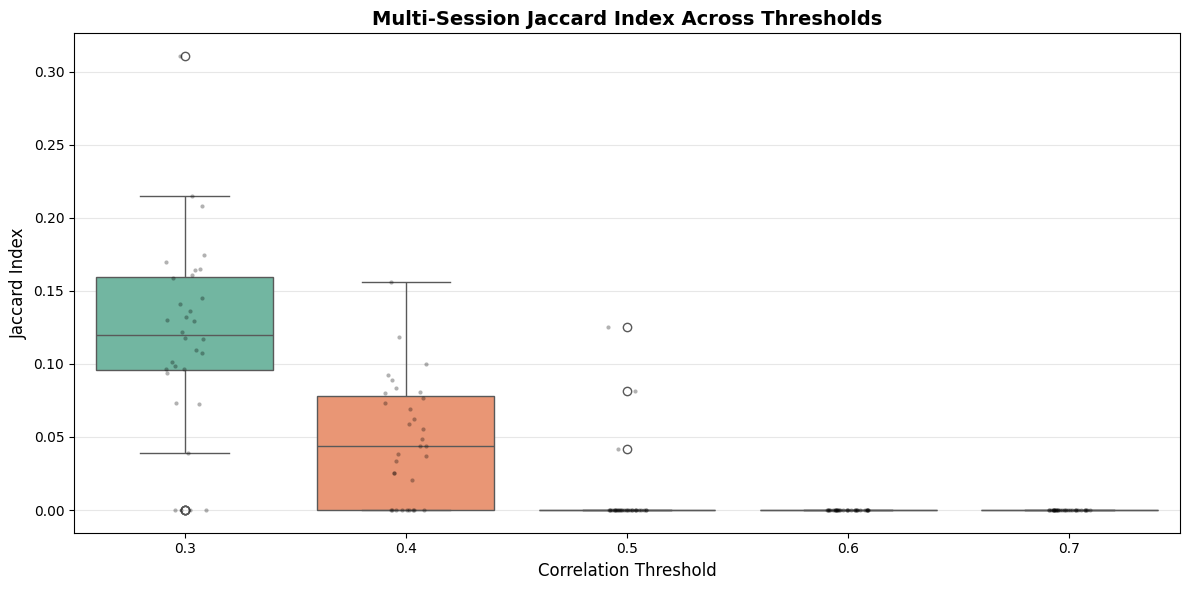

Saved: Multi_Session_Jaccard_Output/jaccard_vs_threshold_boxplot.png


In [9]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=results_df, x='threshold', y='jaccard_index', palette='Set2')
sns.stripplot(data=results_df, x='threshold', y='jaccard_index', color='black', alpha=0.3, size=3)
plt.xlabel('Correlation Threshold', fontsize=12)
plt.ylabel('Jaccard Index', fontsize=12)
plt.title('Multi-Session Jaccard Index Across Thresholds', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'jaccard_vs_threshold_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'jaccard_vs_threshold_boxplot.png'}")

### 5.3 Per-Subject Jaccard Index Comparison

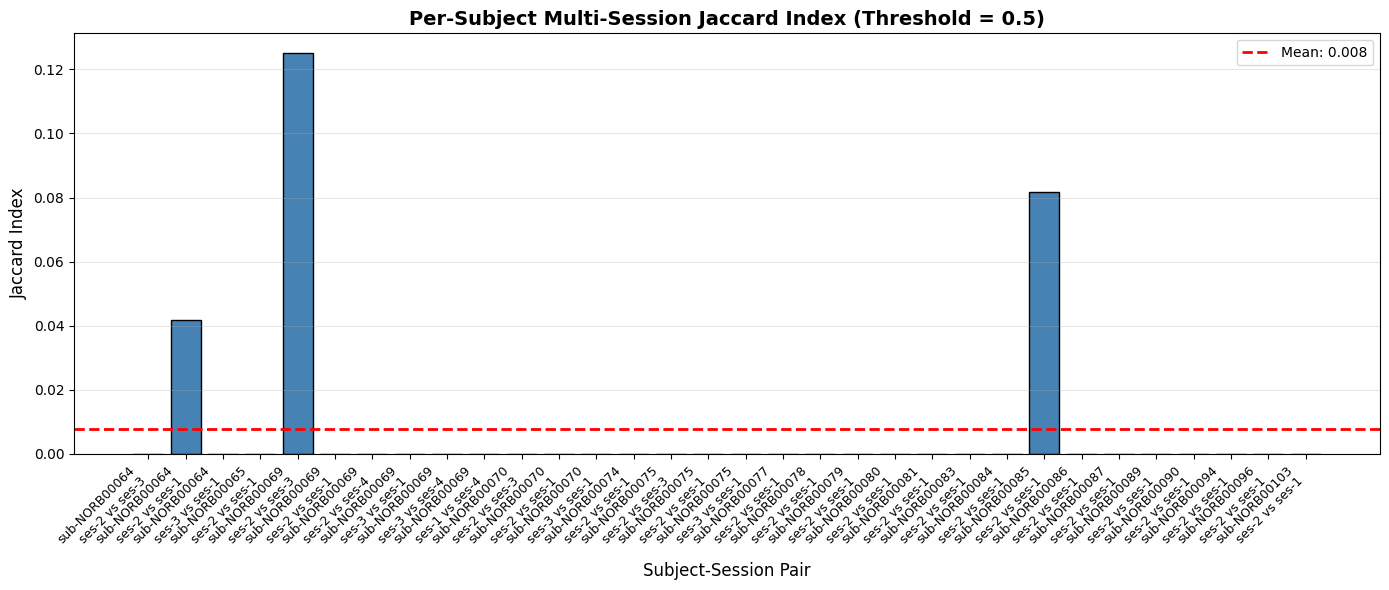

Saved: Multi_Session_Jaccard_Output/per_subject_jaccard_comparison.png


In [10]:
# Focus on threshold = 0.5 for per-subject comparison
threshold_05 = results_df[results_df['threshold'] == 0.5].copy()
threshold_05['pair_label'] = threshold_05['subject_id'] + '\n' + threshold_05['session1'] + ' vs ' + threshold_05['session2']

plt.figure(figsize=(14, 6))
plt.bar(range(len(threshold_05)), threshold_05['jaccard_index'], color='steelblue', edgecolor='black')
plt.axhline(threshold_05['jaccard_index'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {threshold_05["jaccard_index"].mean():.3f}')
plt.xticks(range(len(threshold_05)), threshold_05['pair_label'], rotation=45, ha='right', fontsize=9)
plt.xlabel('Subject-Session Pair', fontsize=12)
plt.ylabel('Jaccard Index', fontsize=12)
plt.title('Per-Subject Multi-Session Jaccard Index (Threshold = 0.5)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'per_subject_jaccard_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'per_subject_jaccard_comparison.png'}")

### 5.4 Correlation Heatmap for One Example Subject

Example visualization: sub-NORB00064
Sessions: ses-2 vs ses-3


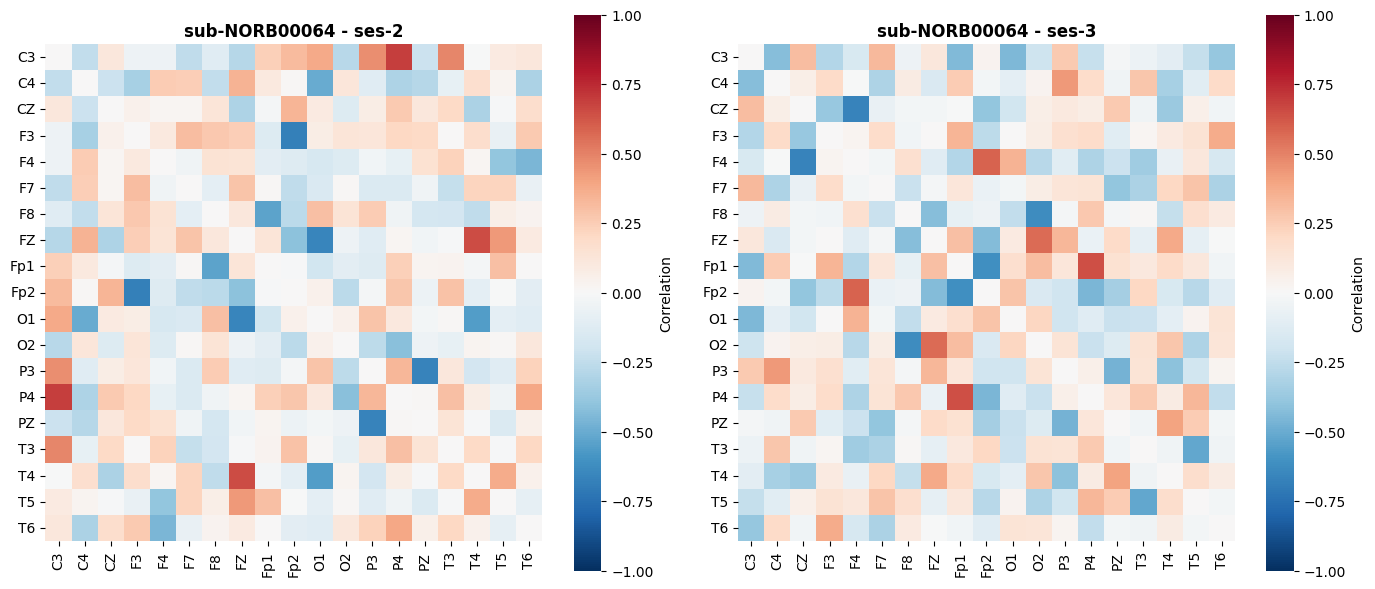

Saved: Multi_Session_Jaccard_Output/correlation_heatmap_sub-NORB00064.png


In [11]:
# Pick the first multi-session subject as example
example_subject = multi_session_subjects[0]
example_sessions = summary_df[summary_df['subject_id'] == example_subject]['session_id'].tolist()[:2]

print(f"Example visualization: {example_subject}")
print(f"Sessions: {example_sessions[0]} vs {example_sessions[1]}")

# Load data
epochs_data1, meta1 = load_preprocessed_epochs(example_subject, example_sessions[0], PREPROCESSED_DIR)
epochs_data2, meta2 = load_preprocessed_epochs(example_subject, example_sessions[1], PREPROCESSED_DIR)

# Align channels
aligned_data1, aligned_data2, common_channels = align_channels(
    epochs_data1, meta1['channels'],
    epochs_data2, meta2['channels']
)

# Compute correlation matrices
corr_matrix1 = compute_correlation_matrix(aligned_data1)
corr_matrix2 = compute_correlation_matrix(aligned_data2)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Session 1
sns.heatmap(corr_matrix1, xticklabels=common_channels, yticklabels=common_channels, 
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True, ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title(f'{example_subject} - {example_sessions[0]}', fontsize=12, fontweight='bold')

# Session 2
sns.heatmap(corr_matrix2, xticklabels=common_channels, yticklabels=common_channels, 
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True, ax=axes[1], cbar_kws={'label': 'Correlation'})
axes[1].set_title(f'{example_subject} - {example_sessions[1]}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'correlation_heatmap_{example_subject}.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / f'correlation_heatmap_{example_subject}.png'}")

## Step 6: Interpretation & Key Findings

In [12]:
print("="*60)
print("KEY FINDINGS")
print("="*60)

print(f"\n1. DATASET OVERVIEW")
print(f"   - Multi-session subjects: {len(multi_session_subjects)}")
print(f"   - Total session pairs analyzed: {len(results_df) // len(THRESHOLDS)}")

print(f"\n2. JACCARD INDEX SUMMARY (across all thresholds)")
print(f"   - Overall mean: {results_df['jaccard_index'].mean():.3f}")
print(f"   - Overall median: {results_df['jaccard_index'].median():.3f}")
print(f"   - Overall std: {results_df['jaccard_index'].std():.3f}")
print(f"   - Range: {results_df['jaccard_index'].min():.3f} - {results_df['jaccard_index'].max():.3f}")

print(f"\n3. THRESHOLD SENSITIVITY")
for threshold in THRESHOLDS:
    data = results_df[results_df['threshold'] == threshold]
    print(f"   Threshold {threshold}: Mean = {data['jaccard_index'].mean():.3f}, Median = {data['jaccard_index'].median():.3f}")

print(f"\n4. BEST AND WORST SIMILARITIES (threshold = 0.5)")
threshold_05 = results_df[results_df['threshold'] == 0.5].copy()
best = threshold_05.nlargest(3, 'jaccard_index')
worst = threshold_05.nsmallest(3, 'jaccard_index')

print("   Most similar session pairs:")
for _, row in best.iterrows():
    print(f"     {row['subject_id']} ({row['session1']} vs {row['session2']}): {row['jaccard_index']:.3f}")

print("   Least similar session pairs:")
for _, row in worst.iterrows():
    print(f"     {row['subject_id']} ({row['session1']} vs {row['session2']}): {row['jaccard_index']:.3f}")

print(f"\n5. INTERPRETATION")
mean_jaccard = results_df['jaccard_index'].mean()
if mean_jaccard > 0.6:
    print("   ✓ HIGH similarity between sessions - Networks are stable/reliable")
elif mean_jaccard > 0.4:
    print("   ~ MODERATE similarity - Some consistency but also variability")
else:
    print("   ⚠ LOW similarity - High variability between sessions")
    print("     Consider: Different states, data quality, or developmental changes")

print("\n" + "="*60)

KEY FINDINGS

1. DATASET OVERVIEW
   - Multi-session subjects: 21
   - Total session pairs analyzed: 32

2. JACCARD INDEX SUMMARY (across all thresholds)
   - Overall mean: 0.035
   - Overall median: 0.000
   - Overall std: 0.058
   - Range: 0.000 - 0.311

3. THRESHOLD SENSITIVITY
   Threshold 0.3: Mean = 0.118, Median = 0.120
   Threshold 0.4: Mean = 0.047, Median = 0.043
   Threshold 0.5: Mean = 0.008, Median = 0.000
   Threshold 0.6: Mean = 0.000, Median = 0.000
   Threshold 0.7: Mean = 0.000, Median = 0.000

4. BEST AND WORST SIMILARITIES (threshold = 0.5)
   Most similar session pairs:
     sub-NORB00069 (ses-2 vs ses-3): 0.125
     sub-NORB00085 (ses-2 vs ses-1): 0.082
     sub-NORB00064 (ses-2 vs ses-1): 0.042
   Least similar session pairs:
     sub-NORB00064 (ses-2 vs ses-3): 0.000
     sub-NORB00064 (ses-3 vs ses-1): 0.000
     sub-NORB00065 (ses-2 vs ses-1): 0.000

5. INTERPRETATION
   ⚠ LOW similarity - High variability between sessions
     Consider: Different states, data

## Summary

This analysis calculated Jaccard Index between different recording sessions for infants with multi-session data.

**What we measured:**
- Similarity of brain connectivity networks across sessions
- Stability at multiple correlation thresholds

**Output files:**
1. `multi_session_jaccard_results.csv` - Detailed results for all comparisons
2. `jaccard_summary_by_threshold.csv` - Summary statistics by threshold
3. Various visualization plots

**Next steps:**
- Consider time between sessions (developmental analysis)
- Compare to inter-subject similarity (as a baseline)
- Investigate factors affecting low similarity cases